In [61]:
import torch
import torchvision
import cv2
import matplotlib.pyplot as plt
import numpy as np
import math
from torchvision import transforms as T
%matplotlib inline

In [62]:
# используем предобученную keypointrcnn_resnet50_fpn сеть
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = torchvision.models.detection.keypointrcnn_resnet50_fpn(pretrained=True)
model = model.to(device)  # Перемещение модели на GPU
model.eval()

# создаем список опорных точек
keypoints = ['nose','left_eye','right_eye',\
'left_ear','right_ear','left_shoulder',\
'right_shoulder','left_elbow','right_elbow',\
'left_wrist','right_wrist','left_hip',\
'right_hip','left_knee', 'right_knee', \
'left_ankle','right_ankle']


c:\Users\Ghost\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Ghost\AppData\Local\Programs\Python\Python39\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=KeypointRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=KeypointRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [129]:
def preprocess_video(video_path, target_size=(224, 224), target_fps=30, max_frames=100):
    """
    Предобработка видео
    """
    cap = cv2.VideoCapture(video_path) # загрузка видео 
    frameRate = cap.get(target_fps) # частота кадров
    frame_list = []
    
    while(cap.isOpened()):
        frameId = cap.get(1) # номер текущего кадра
        ret, frame = cap.read()
        if (ret != True or frameId >= max_frames):
            break
        elif (frameId % target_fps == 0):
            # Изменение размера
            frame_resized = cv2.resize(frame, target_size)
            # Конвертация BGR -> RGB
            frame_rgb = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB)
        
        frame_list.append(frame_rgb)
    cap.release()
    #while len(frame_list) < max_frames:
       # frame_list.append(np.zeros((*target_size, 3)))
    return frame_list

def draw_keypoints_per_person(img, all_keypoints, all_scores, confs, keypoint_threshold=2, conf_threshold=0.9):
    # создаем спектр цветов
    cmap = plt.get_cmap('rainbow')
    # создаем копию изображений
    img_copy = img.copy()
    color_id = np.arange(1,255, 255//len(all_keypoints)).tolist()[::-1]
    # для каждого задетектированного человека
    for person_id in range(len(all_keypoints)):
      # проверяем степень уверенности детектора
      if confs[person_id]>conf_threshold:
        # собираем опорные точки конкретного человека
        keypoints = all_keypoints[person_id, ...]
        # собираем скоры для опорных точек
        scores = all_scores[person_id, ...]
        #итерируем по каждому скору
        for kp in range(len(scores)):
            # проверяем степень уверенности детектора опорной точки
            if scores[kp]>keypoint_threshold:
                # конвертируем массив опорных точек в список целых чисел
                keypoint = tuple(map(int, keypoints[kp, :2].detach().numpy().tolist()))
                # выбираем цвет
                color = tuple(np.asarray(cmap(color_id[person_id])[:-1])*255)
                # рисуем кружок радиуса 5 вокруг точки
                cv2.circle(img_copy, keypoint, 5, color, -1)

    return img_copy
def get_limbs_from_keypoints(keypoints):
  limbs = [       
        [keypoints.index('right_eye'), keypoints.index('nose')],
        [keypoints.index('right_eye'), keypoints.index('right_ear')],
        [keypoints.index('left_eye'), keypoints.index('nose')],
        [keypoints.index('left_eye'), keypoints.index('left_ear')],
        [keypoints.index('right_shoulder'), keypoints.index('right_elbow')],
        [keypoints.index('right_elbow'), keypoints.index('right_wrist')],
        [keypoints.index('left_shoulder'), keypoints.index('left_elbow')],
        [keypoints.index('left_elbow'), keypoints.index('left_wrist')],
        [keypoints.index('right_hip'), keypoints.index('right_knee')],
        [keypoints.index('right_knee'), keypoints.index('right_ankle')],
        [keypoints.index('left_hip'), keypoints.index('left_knee')],
        [keypoints.index('left_knee'), keypoints.index('left_ankle')],
        [keypoints.index('right_shoulder'), keypoints.index('left_shoulder')],
        [keypoints.index('right_hip'), keypoints.index('left_hip')],
        [keypoints.index('right_shoulder'), keypoints.index('right_hip')],
        [keypoints.index('left_shoulder'), keypoints.index('left_hip')]
        ]
  return limbs
def draw_skeleton_per_person(img, all_keypoints, all_scores, confs, keypoint_threshold=2, conf_threshold=0.9):
    cmap = plt.get_cmap('rainbow')
    img_copy = img.copy()
    limbs = get_limbs_from_keypoints(keypoints)  # Добавляем эту строку
    
    if len(all_keypoints) > 0:
        colors = np.arange(1, 255, 255//len(all_keypoints)).tolist()[::-1]
        for person_id in range(len(all_keypoints)):
            if confs[person_id] > conf_threshold:
                keypoints_person = all_keypoints[person_id, ...]

                for limb_id in range(len(limbs)):
                    # ДОБАВЛЯЕМ .cpu() перед .numpy()
                    limb_loc1 = keypoints_person[limbs[limb_id][0], :2].cpu().detach().numpy().astype(np.int32)
                    limb_loc2 = keypoints_person[limbs[limb_id][1], :2].cpu().detach().numpy().astype(np.int32)
                    limb_score = min(all_scores[person_id, limbs[limb_id][0]], all_scores[person_id, limbs[limb_id][1]])
                    
                    if limb_score > keypoint_threshold:
                        color = tuple(np.asarray(cmap(colors[person_id])[:-1]) * 255)
                        cv2.line(img_copy, tuple(limb_loc1), tuple(limb_loc2), color, 5)

    return img_copy
def person_keypoints(all_keypoints, all_scores, confs, conf_threshold=0.9):
    Keypoints = None
    Scores = None
    for person_id in range(len(all_keypoints)):
        if confs[person_id] > conf_threshold:
            Keypoints = all_keypoints[person_id, ...].detach()[:,:-1]
            Scores = all_scores[person_id, ...].cpu().detach().numpy()
    return Keypoints, Scores
def cosine_distance(pose1, pose2):
    lst = []
    for i in range(len(pose1)):
        cossin = pose1[i].dot(np.transpose(pose2[i])) / (
            np.linalg.norm(pose1[i]) * np.linalg.norm(pose2[i])
        )
        lst.append(cossin)
    dist = np.array(lst).reshape(-1,1)
    return dist


def weight_distance(pose1, pose2, conf1):
    # D(U,V) = (1 / sum(conf1)) * sum(conf1 * ||pose1 - pose2||) = sum1 * sum2

    sum1 = 1 / np.sum(conf1)
    sum2 = 0

    for i in range(len(pose1)):
        # каждый индекс i имеет x и y, у которых одинаковая оценка достоверности
        conf_ind = math.floor(i / 2)
        sum2 = conf1[conf_ind] * abs(pose1[i] - pose2[i])

    weighted_dist = sum1 * sum2

    return weighted_dist

def Frame_comparison(Example, imitation):
    model_key_points, Y_scores = person_keypoints(Example["keypoints"], Example["keypoints_scores"], Example["scores"])
    input_key_points, X_scores = person_keypoints(imitation["keypoints"], imitation["keypoints_scores"], imitation["scores"])
 
    model_key_points = model_key_points.cpu().numpy()
    input_key_points = input_key_points.cpu().numpy()
 
    pad = lambda x: np.hstack((x, np.ones((x.shape[0], 1))))
    unpad = lambda x: x[:,:-1]
 
    Y = pad(model_key_points)
    X = pad(input_key_points)
    
    A, res, rank, s = np.linalg.lstsq(X, Y, rcond=None)
    A[np.abs(A) < 1e-10] = 0

    transform = lambda x: unpad(np.dot(pad(x), A))
    input_transform = transform(input_key_points)
    
    X = input_transform
    Y = unpad(Y)
    
    pose1 = Y
    pose2 = X
    conf1 = X_scores
    
    dist = cosine_distance(pose1, pose2)
    weighted_dist = weight_distance(pose1, pose2, conf1)
    

    return dist, weighted_dist
transform = T.Compose([T.ToTensor()])

In [64]:
videoFile_Example = "Data/Reference.mp4"
videoFile_Imitation = "Data/imitation.mp4"
video_Example = preprocess_video(videoFile_Example,max_frames=500)
video_Imitation = preprocess_video(videoFile_Imitation,max_frames=500)
print(len(video_Example))
print(len(video_Imitation))

500
500


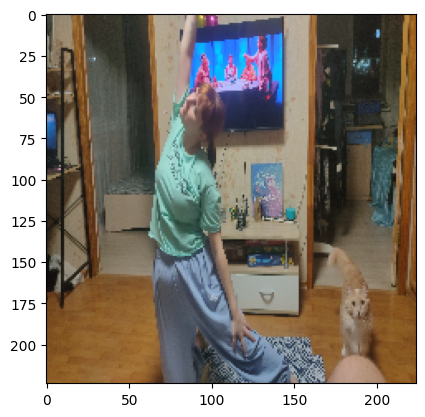

In [ ]:

plt.imshow(video_Imitation[-1])

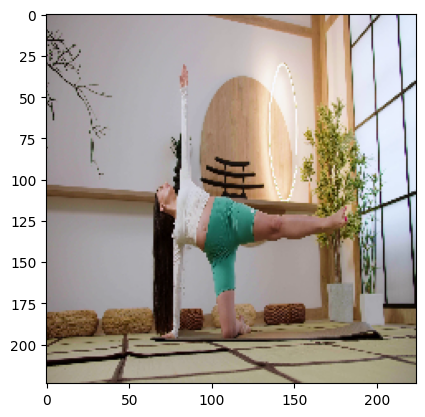

In [73]:
plt.imshow(video_Example[-1])

In [107]:
Example_Modeled = []
for i, frame in enumerate(video_Example):
    img_tensor = transform(frame).to(device)  # Преобразование и перемещение на GPU
    with torch.no_grad():
        result = model([img_tensor])[0]
    Example_Modeled.append(result)
    #print(f"Обработано кадров: {i+1}")

In [136]:
Example_skeletal_frames = []
Imitation_skeletal_frames = []
Combined_skeletal_frames = []
dist_list = []
weighted_dist_list = []
for i, frame in enumerate(video_Imitation):
    img_tensor = transform(frame).to(device)  # Преобразование и перемещение на GPU
    with torch.no_grad():
        result = model([img_tensor])[0]
    dist, weighted_dist = Frame_comparison(Example_Modeled[i], result)
    dist_list.append(dist)
    weighted_dist_list.append(weighted_dist)
    
    Example_skeletal_frames.append(draw_skeleton_per_person(video_Example[i], Example_Modeled[i]["keypoints"], Example_Modeled[i]["keypoints_scores"], Example_Modeled[i]["scores"],keypoint_threshold=2))
    Imitation_skeletal_frames.append(draw_skeleton_per_person(video_Imitation[i], result["keypoints"], result["keypoints_scores"], result["scores"],keypoint_threshold=2))
    Combined_skeletal_frames.append(draw_skeleton_per_person(video_Imitation[i], Example_Modeled[i]["keypoints"], Example_Modeled[i]["keypoints_scores"], Example_Modeled[i]["scores"],keypoint_threshold=2))

averege_dist = sum(dist_list) / len(dist_list)
averege_weighted_dist = sum(weighted_dist_list) / len(weighted_dist_list)
print(f"Косинусная дистанция ={averege_dist}")
print(f"Взвешаная дистанция ={averege_weighted_dist}")

Косинусная дистанция =[[0.99831947]
 [0.99782889]
 [0.99811132]
 [0.9973702 ]
 [0.99736649]
 [0.9980374 ]
 [0.99624222]
 [0.98637986]
 [0.98552181]
 [0.9838377 ]
 [0.98983615]
 [0.998886  ]
 [0.99719781]
 [0.99792585]
 [0.99609646]
 [0.99660519]
 [0.99361443]]
Взвешаная дистанция =[0.8662476  0.09207574]


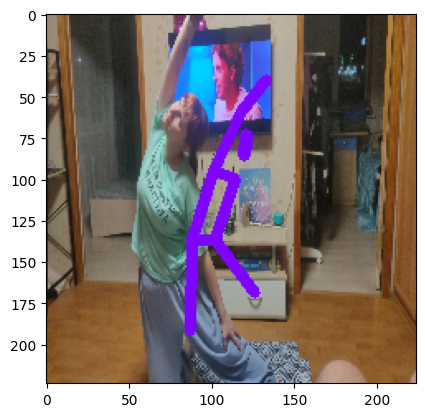

In [142]:
plt.imshow(Combined_skeletal_frames[150])

In [64]:
Example_img_tensor = transform(video_Example[0])
Imitation_img_tensor = transform(video_Imitation[0])

#прогоняем изображение через модель, получаем список
Example = model([Example_img_tensor])[0]
Imitation = model([Imitation_img_tensor])[0]

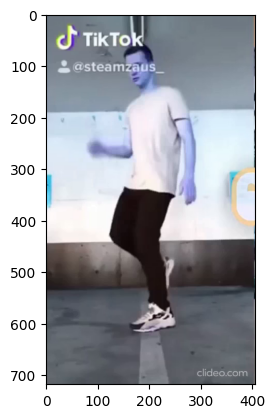

In [65]:
plt.imshow(video_Example[0])

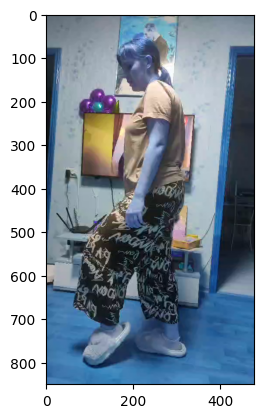

In [66]:
plt.imshow(video_Imitation[0])

In [67]:
Example_keypoints_img = draw_keypoints_per_person(video_Example[0], Example["keypoints"], Example["keypoints_scores"], Example["scores"], keypoint_threshold=2)
Imitation_keypoints_img = draw_keypoints_per_person(video_Imitation[0], Imitation["keypoints"], Imitation["keypoints_scores"], Imitation["scores"], keypoint_threshold=2)

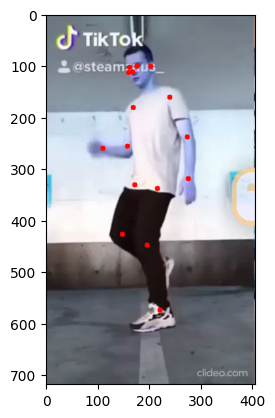

In [68]:
plt.imshow(Example_keypoints_img)

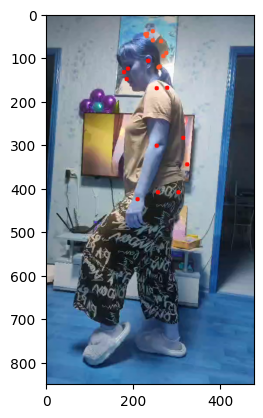

In [69]:
plt.imshow(Imitation_keypoints_img)

In [81]:
Imitation_skeletal_img = draw_skeleton_per_person(video_Imitation[0], Imitation["keypoints"], Imitation["keypoints_scores"], Imitation["scores"],keypoint_threshold=2)
Example_skeletal_img = draw_skeleton_per_person(Imitation_skeletal_img, Example["keypoints"], Example["keypoints_scores"], Example["scores"],keypoint_threshold=2)


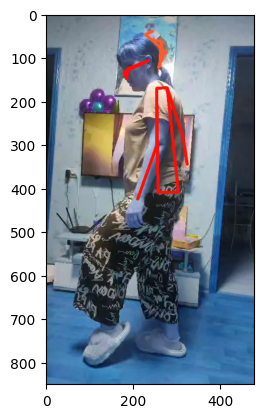

In [82]:
plt.imshow(Imitation_skeletal_img)

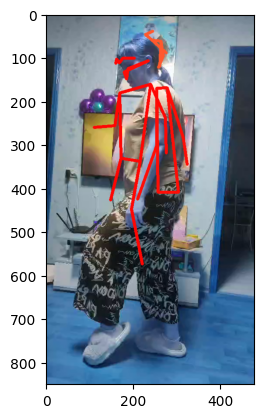

In [83]:
plt.imshow(Example_skeletal_img)

In [9]:

frame = video_Imitation[0]
height, width, layers = frame.shape

video = cv2.VideoWriter('video_name', cv2.VideoWriter_fourcc(*'DIVX'), 5, (width, height))

for i in range(len(video_Imitation)):
        
    video.write(i)

video.release()
print(f"Видео  успешно создано.")


Видео  успешно создано.


In [46]:
from IPython.display import HTML
from base64 import b64encode
mp4 = open('data/dspr_cv_u1_diploma_spr3_2.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

In [47]:
HTML("""
<video controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

In [12]:

limbs = get_limbs_from_keypoints(keypoints)

In [26]:
Example_keypoints_img = draw_keypoints_per_person(Example_img, Example["keypoints"], Example["keypoints_scores"], Example["scores"], keypoint_threshold=2)
Imitation_keypoints_img = draw_keypoints_per_person(Imitation_img, Imitation["keypoints"], Imitation["keypoints_scores"], Imitation["scores"], keypoint_threshold=2)

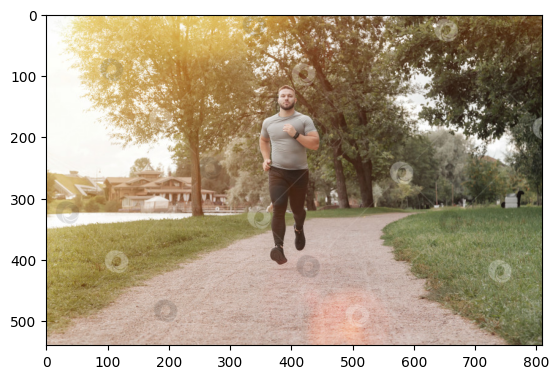

In [27]:
plt.imshow(Example_img)


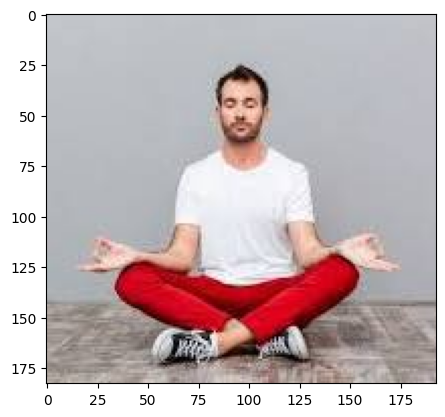

In [28]:
plt.imshow(Imitation_img)

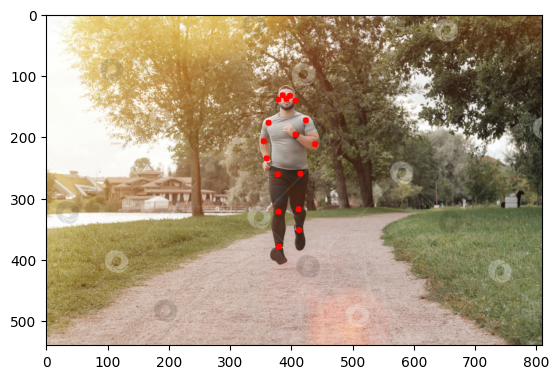

In [29]:
plt.imshow(Example_keypoints_img)

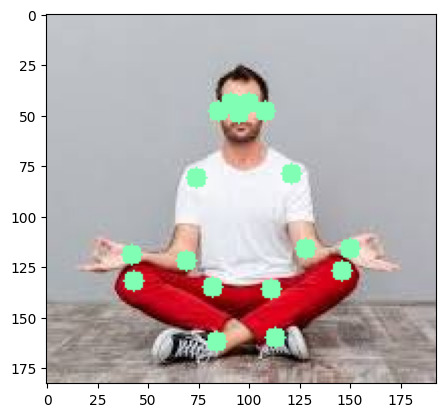

In [30]:
plt.imshow(Imitation_keypoints_img)

In [43]:
Example_skeletal_img = draw_skeleton_per_person(Example_img, Example["keypoints"], Example["keypoints_scores"], Example["scores"],keypoint_threshold=2)
Imitation_skeletal_img = draw_skeleton_per_person(Example_skeletal_img, Imitation["keypoints"], Imitation["keypoints_scores"], Imitation["scores"],keypoint_threshold=2)

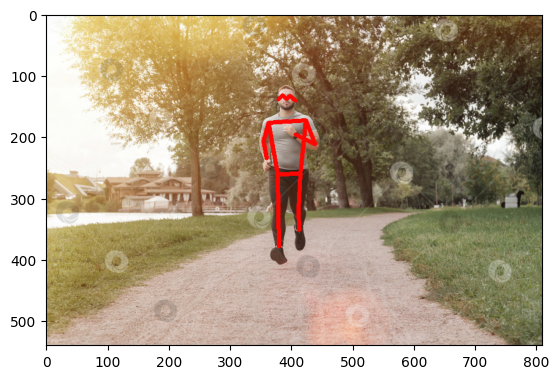

In [41]:
plt.imshow(Example_skeletal_img)

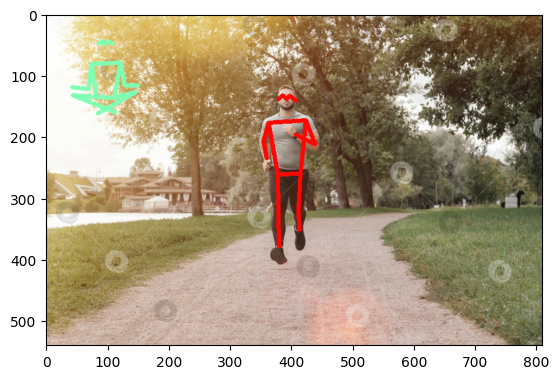

In [44]:
plt.imshow(Imitation_skeletal_img)